In [1]:
import pandas as pd
import numpy as np
import regex as re
import tensorflow as tf
import unicodedata
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.keras.utils.set_random_seed(42)

In [2]:
print('hello world')
!pip install -U "torchao>=0.16.0"
!pip install -q evaluate sacrebleu sacremoses


hello world
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 64.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 24.5 MB/s eta 0:00:00


In [3]:
# RUN if using google colab
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import pathlib

path = pathlib.Path('/content/drive/MyDrive/areola-joshua_eng-Yor/Train.csv')
print(path.exists())
data = pd.read_csv(path)
data.head()

Mounted at /content/drive
True


,ID,Yoruba,English
0,ID_AAJEQLCz,A ṣètò Ìgbìmọ̀ Tó Ń Ṣètò Ìrànwọ́ Nígbà Àjálù l...,A Disaster Relief Committee was formed to orga...
1,ID_AASNedba,"Ìrọ̀lẹ́ May 22, 2018 ni wọ́n fàṣẹ ọba mú Arákù...",Brother Solovyev was arrested on the evening o...
2,ID_AAeQrhMq,Iléeṣẹ́ Creative Commons náà,Creative Commons the Organization
3,ID_AAxlMgPP,"Pè̩lú Egypt, Morocco àti Tunisia tí wó̩n ti lo...","With Egypt, Morocco and Tunisia out of the Wor..."
4,ID_ABKuMKSx,Adájọ́ àgbà lórílẹ̀ èdè Náíjíríà (Attorney Gen...,"The Attorney General of the Federation, Justic..."


In [4]:
def load_data(file_path):
    """
    Load the dataset from a CSV file.

    Args:
        file_path (str): Path to the CSV file.
    """
    
    data = pd.read_csv(file_path)

    # Normalize column names in case of extra whitespace
    data.columns = [col.strip() for col in data.columns]

    # Ensure the expected columns exist
    if 'ID' not in data.columns:
        data.insert(0, 'ID', range(len(data)))
    if 'Yoruba' not in data.columns:
        raise ValueError("Expected a 'Yoruba' column in the dataset")

    # Keep only the needed columns and remove empty/duplicate rows
    data = data.dropna().drop_duplicates().reset_index(drop=True)
    
    data = data.drop(columns=['ID'])

    print(f"columns = {data.columns.tolist()}")
    return data

In [5]:
import pathlib
# Load the dataset for local user
#path = pathlib.Path('areola-joshua_eng-Yor/Train.csv')

#For colab user
path = pathlib.Path('/content/drive/MyDrive/areola-joshua_eng-Yor/Train.csv')
data = load_data(path)
data

columns = ['Yoruba', 'English']


,Yoruba,English
0,A ṣètò Ìgbìmọ̀ Tó Ń Ṣètò Ìrànwọ́ Nígbà Àjálù l...,A Disaster Relief Committee was formed to orga...
1,"Ìrọ̀lẹ́ May 22, 2018 ni wọ́n fàṣẹ ọba mú Arákù...",Brother Solovyev was arrested on the evening o...
2,Iléeṣẹ́ Creative Commons náà,Creative Commons the Organization
3,"Pè̩lú Egypt, Morocco àti Tunisia tí wó̩n ti lo...","With Egypt, Morocco and Tunisia out of the Wor..."
4,Adájọ́ àgbà lórílẹ̀ èdè Náíjíríà (Attorney Gen...,"The Attorney General of the Federation, Justic..."
...,...,...
10049,Àwọn Ẹlẹ́rìí Jèhófà Ti Ṣe Tán Láti Bẹ̀rẹ̀ Àtún...,Witnesses Poised to Launch Major Rebuilding Wo...
10050,Asárélówó ń bẹ lọ́nà ogun; Apọ̀ṣẹ̀ṣẹ̀ ń bẹ lọ́...,He-who-hurries-after-riches is on his way to b...
10051,Ọ̀mọ ilé ìgbìmọ̀ Aṣojú-ṣòfin tó ń ṣojú Àgbádár...,The assertion was given by a member of the Gre...
10052,"Olùdíje fún ipò asòfin àgbà nínú ẹgbẹ́, All Pr...",The candidate of the All Progressives Congress...


In [6]:
Batch_size = 64
BUFFER_SIZE = len(data)

In [8]:
from tokenizers import Tokenizer, decoders, pre_tokenizers
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer


def train_BPE_tokenizer(
    sentences, vocab_size, special_tokens=None, end_of_word_suffix="</w>"
):
    """Train a production-ready BPE tokenizer for NMT tasks."""
    if special_tokens is None:
        # Standard special tokens order matters for ID assignment
        special_tokens = ["<pad>", "[START]", "[END]", "<unk>"]

    # 1. Initialize BPE model with byte fallback and word boundaries
    model = BPE(
        unk_token="<unk>",
        end_of_word_suffix=end_of_word_suffix,
        byte_fallback=True,  # Handles unknown characters smoothly
    )
    tokenizer = Tokenizer(model)

    # 2. Pre-tokenization: Split on whitespace & punctuation boundaries
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    # 3. Add Decoder: Ensures subwords are properly recombined back into words
    tokenizer.decoder = decoders.BPEDecoder(suffix=end_of_word_suffix)

    # 4. Trainer configuration
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=special_tokens,
        end_of_word_suffix=end_of_word_suffix,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    )

    # 5. Train model
    tokenizer.train_from_iterator(sentences, trainer=trainer)

    return tokenizer

In [9]:
def normalize_text(text):
    """
    Normalize text while preserving Yoruba diacritics and punctuation.
    """
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s*([?.!,;:])\s*", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text):
    """
    Apply normalized cleaning before tokenization.
    """
    return normalize_text(text)
MAX_LEN = 40
def encode_texts(texts, tokenizer, add_start_end=False, start_token="[START]", end_token="[END]",):
    encoded = []
    
    if add_start_end:
        start_id = tokenizer.token_to_id(start_token)
        end_id = tokenizer.token_to_id(end_token)
        if start_id is None or end_id is None:
            raise ValueError(
                f"Special tokens '{start_token}' or '{end_token}' not found in vocabulary."
            )
    for text in texts:
        ids = tokenizer.encode(text).ids

        # 2. Truncate and wrap with special tokens if enabled
        if add_start_end:
            ids = [start_id] + ids[: MAX_LEN - 2] + [end_id]
        else:
            ids = ids[:MAX_LEN]
        encoded.append(ids)
    return encoded

import tensorflow as tf


def make_dataset(en_texts, yo_texts, en_tokenizer, yo_tokenizer, batch_size=64):
    en_pad_id = en_tokenizer.token_to_id("<pad>")
    yo_pad_id = yo_tokenizer.token_to_id("<pad>")

    # 1. Encode text via Rust-accelerated batching
    en_encoded = encode_texts(en_texts, en_tokenizer, add_start_end=False)
    yo_encoded = encode_texts(yo_texts, yo_tokenizer, add_start_end=True)

    # 2. Generator to yield unpadded raw sequences (Zero extra memory allocations)
    def generator():
        for en, yo in zip(en_encoded, yo_encoded):
            dec_in = yo[:-1]  # Drop [END] token
            dec_tar = yo[1:]  # Drop [START] token
            yield (en, dec_in), dec_tar

    # 3. Define output signature
    output_signature = (
        (
            tf.TensorSpec(shape=(None,), dtype=tf.int32),  # encoder_input
            tf.TensorSpec(shape=(None,), dtype=tf.int32),  # decoder_input
        ),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),  # decoder_target
    )

    # 4. Construct dataset and apply dynamic padded batching
    dataset = tf.data.Dataset.from_generator(
        generator, output_signature=output_signature
    )

    dataset = (
    dataset.shuffle(buffer_size=len(en_encoded))
    .padded_batch(
        batch_size,
        padded_shapes=(([None], [None]), [None]),
        padding_values=(
            (
                tf.constant(en_pad_id, dtype=tf.int32),
                tf.constant(yo_pad_id, dtype=tf.int32),
            ),
            tf.constant(yo_pad_id, dtype=tf.int32),
        ),
    )
    .prefetch(tf.data.AUTOTUNE)
)

    return dataset, en_pad_id, yo_pad_id


In [10]:
# Prepare the tokenizer and dataset splits
max_vocab_size = 8000

english_sentences = [preprocess_text(t) for t in data["English"].tolist()]
yoruba_sentences = [preprocess_text(t) for t in data["Yoruba"].tolist()]

en_tokenizer = train_BPE_tokenizer(english_sentences, max_vocab_size)
yo_tokenizer = train_BPE_tokenizer(yoruba_sentences, max_vocab_size)

# Print the 50 least frequent tokens to see what the 3k vocab forced the model to create
vocab = yo_tokenizer.get_vocab()
sorted_vocab = sorted(vocab.items(), key=lambda item: item[1])[1000:1050]#, reverse=True)


print("English vocabulary size:", en_tokenizer.get_vocab_size())
print("Yoruba vocabulary size:", yo_tokenizer.get_vocab_size())

indices = np.arange(len(english_sentences))
np.random.shuffle(indices)
train_split = int(len(indices) * 0.8)

train_idx = indices[:train_split]
val_idx = indices[train_split:]

train_en = [english_sentences[i] for i in train_idx]
train_yo = [yoruba_sentences[i] for i in train_idx]
val_en = [english_sentences[i] for i in val_idx]
val_yo = [yoruba_sentences[i] for i in val_idx]

train_dataset, en_pad_id, yo_pad_id = make_dataset(train_en, train_yo, en_tokenizer, yo_tokenizer, batch_size=Batch_size)
val_dataset, _, _ = make_dataset(val_en, val_yo, en_tokenizer, yo_tokenizer, batch_size=Batch_size)

input_vocab_size = en_tokenizer.get_vocab_size()
target_vocab_size = yo_tokenizer.get_vocab_size()

#print("Encoder max length:", encoder_maxlen)
#print("Decoder max length:", decoder_maxlen)


English vocabulary size: 8000
Yoruba vocabulary size: 8000


In [11]:
sample_text = "Nínú isẹ́ ìkíni ti Olórí ilé ìgbìmọ̀ asòfin Dokita Bukola Saraki tó fi gbóríyìn fún àwọn òṣìṣẹ́ fún ipa tí wón nko nínú ìdàgbàsókè ilẹ̀ wa, ninu àtèjáde ti akọ̀wé fún Dókítà Saraki buwọ́lù ìyen Ogbeni Yusuph Olaniyonu ló ti gbóríyín fún àwọn tó gbèrò láti jóòko ìpàdé pọ̀ pẹ̀lú ìjoba láti so àsoyèpọ̀ lórí ìdàmú tó n kójú àwọn òṣìṣẹ́."

# Encode text
encoded_ids = yo_tokenizer.encode(sample_text).ids
tokens = yo_tokenizer.encode(sample_text).tokens
print('8000 vocab')
print(f"Token Count: {len(tokens)}")
print(f"Tokens: {tokens}")

8000 vocab
Token Count: 95
Tokens: ['N', 'í', 'nú</w>', 'isẹ́</w>', 'ìkíni</w>', 'ti</w>', 'O', 'lórí</w>', 'ilé</w>', 'ìgbìmọ̀</w>', 'asòfin</w>', 'D', 'ok', 'ita</w>', 'B', 'uk', 'ola</w>', 'S', 'ar', 'aki</w>', 'tó</w>', 'fi</w>', 'gbóríyìn</w>', 'fún</w>', 'àwọn</w>', 'òṣìṣẹ́</w>', 'fún</w>', 'ipa</w>', 'tí</w>', 'wón</w>', 'n', 'ko</w>', 'nínú</w>', 'ìdàgbàsókè</w>', 'ilẹ̀</w>', 'wa</w>', ',</w>', 'ninu</w>', 'àt', 'è', 'jáde</w>', 'ti</w>', 'akọ̀wé</w>', 'fún</w>', 'D', 'ók', 'ítà</w>', 'S', 'ar', 'aki</w>', 'buwọ́', 'lù</w>', 'ìyen</w>', 'O', 'gbeni</w>', 'Y', 'us', 'up', 'h</w>', 'O', 'l', 'ani', 'y', 'on', 'u</w>', 'ló</w>', 'ti</w>', 'gbó', 'rí', 'yín</w>', 'fún</w>', 'àwọn</w>', 'tó</w>', 'gbèrò</w>', 'láti</w>', 'jóò', 'ko</w>', 'ìpàdé</w>', 'pọ̀</w>', 'pẹ̀lú</w>', 'ìjoba</w>', 'láti</w>', 'so</w>', 'às', 'oyè', 'pọ̀</w>', 'lórí</w>', 'ìd', 'àmú</w>', 'tó</w>', 'n</w>', 'kójú</w>', 'àwọn</w>', 'òṣìṣẹ́</w>', '.</w>']


 would tf.sin be better? --- YES, but learned embeddings are often more flexible and can capture more complex positional relationships than fixed sinusoidal embeddings. Learned embeddings allow the model to adapt to the specific dataset and task, potentially leading to better performance. However, sinusoidal embeddings have the advantage of being deterministic and not requiring additional parameters to learn. The choice between learned and sinusoidal embeddings can depend on the specific application and empirical results.

In [12]:
# Define a compact transformer-style model with attention
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_embedding = tf.keras.layers.Embedding(vocab_size, d_model) # what this does is to convert the token ids into dense vectors of size d_model
        self.position_embedding = tf.keras.layers.Embedding(max_len, d_model) # this creates a positional embedding for each position in the input sequence, allowing the model to understand the order of tokens
        # since there are no recurrent or convolutional layers, the model needs a way to know the position of each token in the sequence, which is what the positional embedding provides
        # The model must learn the positions of tokens in the sequence, which is crucial for understanding the context and relationships between words in a sentence.
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        # pos
        positions = self.position_embedding(positions)
        return self.token_embedding(x) + positions # shape will be (batch_size, seq_len, d_model), each position has a learned positional embedding vector

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model) # using multi head attention adds an extra dimension
        # we should use a single head here since the model is small and we want to keep it lightweight, but we can still use multiple heads if needed
        # This automatically computes the attention scores, weight matrices and even softmax for us, so we don't have to implement it manually. It also handles the multi-head attention mechanism, which allows the model to focus on different parts of the input sequence simultaneously.
        # this is self attention, where the query, key, and value are all the same input (the encoder input). It allows the model to learn relationships between different positions in the input sequence.
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"), # (batch_size, seq_len, dff)
            tf.keras.layers.Dense(d_model), # (batch_size, seq_len, d_model) back again
            # feedforward layer that transforms the data but still returns it in d_model dimension
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training, mask=None):
        attn_output = self.mha(query=x, value=x, key=x, attention_mask=mask) # takes in a padding mask to prevent calculating scores for padded tokens
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output) # add original input back to the attention output (residual connection) and normalize
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output) # residual connections and layernormalization cheat codes

class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.mha1 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model) 
        self.mha2 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model) # we ensured encoder mha outputs d_model so shapes can match when taking attention with decoder
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)
        self.dropout3 = tf.keras.layers.Dropout(dropout)

    def call(self, x, enc_output, training, look_ahead_mask=None, padding_mask=None):
        attn1 = self.mha1(query=x, value=x, key=x, attention_mask=look_ahead_mask) #second mha needs both look_ahead and padding_mask
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(x + attn1)

        attn2 = self.mha2(query=out1, value=enc_output, key=enc_output, attention_mask=padding_mask)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        return self.layernorm3(out2 + ffn_output)

class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, pe_input, pe_target, dropout=0.1, en_pad_id=None, yo_pad_id=None):
        super().__init__()
        self.encoder_embedding = PositionalEmbedding(input_vocab_size, d_model, pe_input)
        self.decoder_embedding = PositionalEmbedding(target_vocab_size, d_model, pe_target)
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.decoder_layers = [TransformerDecoderLayer(d_model, num_heads, dff, dropout) for _ in range(num_layers)]
        self.final_layer = tf.keras.layers.Dense(target_vocab_size)
        self.en_pad_id = en_pad_id
        self.yo_pad_id = yo_pad_id

    def create_padding_mask(self, seq, pad_id):
        mask = tf.math.not_equal(seq, pad_id)  # True = KEEP, False = MASK
        return mask[:, tf.newaxis, tf.newaxis, :]

    def create_look_ahead_mask(self, size):
        mask = tf.linalg.band_part(tf.ones((size, size)), -1, 0)  # True = LOWER TRIANGLE
        return tf.cast(mask[tf.newaxis, tf.newaxis, :, :], tf.bool)

    def combined_padding_look_ahead_mask(self, seq, pad_id, size):
        # Combine with logical_and so BOTH conditions must be True to attend
        return tf.math.logical_and(
            self.create_look_ahead_mask(size), 
            self.create_padding_mask(seq, pad_id)
        )

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs

        enc_padding_mask = self.create_padding_mask(enc_input, self.en_pad_id)

        dec_seq_len = tf.shape(dec_input)[1]
        look_ahead_mask = self.combined_padding_look_ahead_mask(dec_input, self.yo_pad_id, dec_seq_len)

        cross_attention_padding_mask = self.create_padding_mask(enc_input, self.en_pad_id)

        enc_output = self.encoder_embedding(enc_input)
        for layer in self.encoder_layers:
            enc_output = layer(enc_output, training=training, mask=enc_padding_mask)

        dec_output = self.decoder_embedding(dec_input)
        for layer in self.decoder_layers:
            dec_output = layer(dec_output, enc_output, training=training,
                               look_ahead_mask=look_ahead_mask,
                               padding_mask=cross_attention_padding_mask)

        return self.final_layer(dec_output)



In [21]:
# only run if you are retraining the model, otherwise load the saved model
num_layers = 2
embedding_dim = 128
dff = 256
num_heads = 4
encoder_maxlen = 40
decoder_maxlen = 40

transformer = Transformer(
    num_layers=num_layers,
    d_model=embedding_dim,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    pe_input=encoder_maxlen,
    pe_target=decoder_maxlen,
    dropout=0.1,
    en_pad_id=en_pad_id,
    yo_pad_id=yo_pad_id,
)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, yo_pad_id)) # same tensor as real but pading tokens are zero non-padding token are 1
    loss_ = loss_object(real, pred) # calculate cross entropy loss
    loss_ *= tf.cast(mask, dtype=loss_.dtype) # apply masking(hadamaard product)
    return tf.reduce_sum(loss_) / tf.reduce_sum(tf.cast(mask, dtype=loss_.dtype)) # this is accuracy

def accuracy_function(real, pred):
    accuracies = tf.equal(tf.cast(real, tf.int64), tf.argmax(pred, axis=-1))
    mask = tf.math.logical_not(tf.math.equal(real, yo_pad_id))
    accuracies = tf.math.logical_and(mask, accuracies)
    
    return tf.reduce_sum(tf.cast(accuracies, dtype=tf.float32)) / tf.reduce_sum(tf.cast(mask, dtype=tf.float32))

transformer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_function,
    metrics=[accuracy_function],
)

transformer.summary()

epochs = 70
history = transformer.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    #callbacks=[
    #    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

    #],# might be a good idea to repeat the training run with both train and most test data combined to see if the model can learn better with more data, but we need to be careful about overfitting.
)
# strongly realize the model will completely overfit on the small dataset, but if we use earlystopping due to overfitting we wouldnt have enough epochs to predict anything even remotely sensible for a 10k dataset

Model: "transformer_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positional_embedding_2          │ ?                      │   0 (unbuilt) │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_3          │ ?                      │   0 (unbuilt) │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_2     │ ?                      │   0 (unbuilt) │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_3     │ ?                      │   0 (unbuilt) │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer_2     │ ?                      │   0 (unbuilt) │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer_3     │ ?                      │   0 (unbuilt) │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_layer_2' (of type TransformerEncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_layer_3' (of type TransformerEncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


    126/Unknown 53s 157ms/step - accuracy_function: 0.0319 - loss: 8.5776

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


126/126 ━━━━━━━━━━━━━━━━━━━━ 59s 208ms/step - accuracy_function: 0.0413 - loss: 8.1741 - val_accuracy_function: 0.0437 - val_loss: 7.4205
Epoch 2/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy_function: 0.0667 - loss: 6.9911 - val_accuracy_function: 0.0775 - val_loss: 6.7278
Epoch 3/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy_function: 0.0823 - loss: 6.5903 - val_accuracy_function: 0.0852 - val_loss: 6.5406
Epoch 4/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy_function: 0.0951 - loss: 6.3886 - val_accuracy_function: 0.1047 - val_loss: 6.3264
Epoch 5/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy_function: 0.1275 - loss: 6.1491 - val_accuracy_function: 0.1392 - val_loss: 6.1041
Epoch 6/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy_function: 0.1563 - loss: 5.9077 - val_accuracy_function: 0.1578 - val_loss: 5.9062
Epoch 7/70
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy_function: 0.1737 - loss: 5.6883 - val_accuracy_function: 0.1703

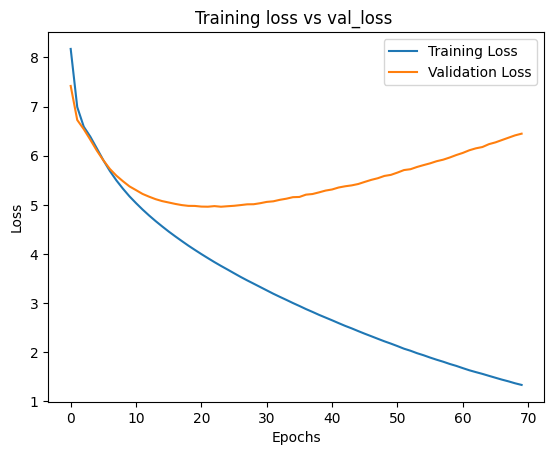

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training loss vs val_loss ") #we see overfitting due to small dataset and lack of examples for the model to learn complex abstract representations therefore it defaults to solving the translation dataset like a math problem
plt.legend()
plt.show()
# The only way to salvage this model is to train it on a larger dataset, or to use a pre-trained model and fine-tune it on this dataset. e.g like No Language Left Behind (NLLB) model from Meta AI, which is a state-of-the-art multilingual translation model that supports many low-resource languages, including Yoruba. Fine-tuning such a model on your dataset could yield better results than training from scratch.
    

In [23]:
#to save model if training
save_path = '/content/drive/MyDrive/areola-joshua_eng-Yor/yoruba_transformer_70ep.weights.h5'
transformer.save_weights(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/areola-joshua_eng-Yor/yoruba_transformer_70ep.weights.h5


In [10]:
import tensorflow as tf


# 1. Re-instantiate architecture
transformer = Transformer(
    num_layers=2,
    d_model=128,
    num_heads=4,
    dff=256,
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    pe_input=40,
    pe_target=40,
    dropout=0.1,
    en_pad_id=en_pad_id,
    yo_pad_id=yo_pad_id,
)

# 2. Build layer shapes via dummy call
dummy_enc = tf.zeros((1, 40), dtype=tf.int32)
dummy_dec = tf.zeros((1, 40), dtype=tf.int32)
_ = transformer((dummy_enc, dummy_dec), training=False)

# 3. Load saved weights
transformer.load_weights(
    "/content/drive/MyDrive/areola-joshua_eng-Yor/yoruba_transformer_70ep.weights.h5"
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_layer' (of type TransformerEncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_layer_1' (of type TransformerEncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [24]:
# so we would be performing inference here, we don't need to create 
# padding masks, we just use the weights from the training run to generate translations for new English sentences. We will use the trained transformer model to predict the Yorùbá translation for a given English input.
def predict_translation(input_sentence, transformer, en_tokenizer, yo_tokenizer, max_len=50):
    import numpy as np
    
    # 1. Standard text cleaning and source encoding
    input_sentence = preprocess_text(input_sentence)
    input_ids = en_tokenizer.encode(input_sentence).ids[:max_len]
    input_ids = tf.expand_dims(input_ids, 0)  # Shape: (1, en_seq_len)

    # 2. Get exact registered special token integers
    start_token_id = yo_tokenizer.token_to_id("[START]")
    end_token_id = yo_tokenizer.token_to_id("[END]")
    
    # Initialize decoder tracking matrix as a 2D batch explicit tensor: (1, 1)
    decoder_input = tf.expand_dims([start_token_id], 0)  

    for i in range(max_len):
        # Forward execution pass
        predictions = transformer((input_ids, decoder_input), training=False)
        
        # FIX: Directly use Python's built-in 3D tensor slice index.
        # This isolates the (batch=0, last_token=-1, all_logits=:) array cleanly.
        latest_logits = predictions[0, -1, :]  # Shape: (vocab_size,)
        
        # Extract the highest probability token ID as a raw scalar integer
        predicted_id = int(tf.argmax(latest_logits, axis=-1).numpy())
        
        # Stop generating immediately if the model hits the terminating token
        if predicted_id == end_token_id:
            break
            
        # Append the new prediction token ID cleanly along the sequence axis (axis=-1)
        decoder_input = tf.concat([decoder_input, tf.expand_dims([predicted_id], 0)], axis=-1)

    # 3. Extract, flatten, and decode back into a readable string
    predicted_tokens = decoder_input.numpy().flatten()
    return yo_tokenizer.decode(predicted_tokens[1:]) 



# Test your 60% accurate model!
input_phrase = "Hello, how are you?"
print("Yorùbá Translation:", predict_translation(input_phrase, transformer, en_tokenizer, yo_tokenizer))


Yorùbá Translation: báwo ni o ṣe ?


In [25]:
input_sentence = "Hello, my name is Iyanu"
translation = predict_translation(input_sentence, transformer, en_tokenizer, yo_tokenizer)
print(f"Input: {input_sentence}")
print(f"Predicted Translation: {translation}")

Input: Hello, my name is Iyanu
Predicted Translation: ẹ mọ nǹkan , o wá nǹkan jẹ́ olú ìlú


In [26]:
print("--- Sample Model Translations ---")
for i in range(10):
    src_text = val_en[i]
    ref_text = val_yo[i]
    pred_text = predict_translation(
        src_text, transformer, en_tokenizer, yo_tokenizer
    )

    print(f"[{i+1}]")
    print(f"Input English : {src_text}")
    print(f"Target Yoruba : {ref_text}")
    print(f"Predicted     : {pred_text}")
    print("-" * 50)

--- Sample Model Translations ---
[1]
Input English : whoever leaps up decapitates dance .
Target Yoruba : ẹni tí ó fò sókèé bẹ́ ijó lórí .
Predicted     : ẹni tí a bá pa ẹ́ kọjá .
--------------------------------------------------
[2]
Input English : experience : sylvester turner , the mayor of the city of houston , was impressed by the 50 , 000 jehovah’s witnesses and their guests who came to houston for the convention .
Target Yoruba : ìrírí : inú sylvester turner tó jẹ́ olórí ìlú houston dùn láti rí ẹgbẹ̀rún lọ́nà àádọ́ta (50 , 000) àwọn ẹlẹ́rìí jèhófà àtàwọn àlejò tó wá sí ìlú houston fún àpéjọ náà .
Predicted     : náà : dókítà ní erékùṣù samar pẹ̀lú ẹlẹ́rìí jèhófà tàbí arábìnrin tí ìmìtìtì ilẹ̀ yìí ti wáyé ní ọgọ́rùn - ún méjì ó lé jèhófà kankan .
--------------------------------------------------
[3]
Input English : what kept you so long
Target Yoruba : kí ló mú ẹ pẹ́ , mo ti ń kan ilẹ̀kùn tipẹ́
Predicted     : ẹ wo ẹ gan
--------------------------------------------------
[4]
I

Why Yoruba is Challenging for TranslationLow-Resource Status: Yoruba has fewer digital books, articles, and online texts available for AI training compared to major global languages like English or Spanish. [1] (https://support.google.com/translate/thread/66167436/why-can-t-google-translate-have-reliable-yoruba-translation?hl=en), [2] (https://www.researchgate.net/publication/322569949_Human_Evaluation_of_Yoruba-English_Google_Translation)Tones and Accents: Yoruba is a tonal language where changing the accent mark changes the entire meaning of a word. Machine tools often miss or misplace these tone marks. [1] (https://rising.globalvoices.org/blog/2020/11/20/lost-in-translation-why-google-translate-often-gets-yoruba-and-other-languages-wrong/)Idioms and Proverbs: Complex cultural expressions, proverbs, and deep colloquialisms are frequently mistranslated into confusing or literal word-for-word English. [1] (https://www.ripplesnigeria.com/feature-not-made-for-us-global-ai-translation-tools-distort-nigerian-languages/), [2] (https://www.ktravula.com/2013/08/google-ni-yoruba/)Current PerformanceBasic Communication: The tool works well for simple words, short everyday phrases, and basic sentences.Ongoing Improvements: Google uses advanced machine learning and AI updates to improve low-resource languages, but it still lacks the deep nuance of a human translator

In [27]:
# Load the dataset for local user
#path = pathlib.Path('areola-joshua_eng-Yor/Train.csv')

#For colab user
# Load JSON Lines and flatten the nested translation records
path = pathlib.Path('/content/drive/MyDrive/areola-joshua_eng-Yor/train_mafand_yor.json')

# Increase Dataset with Mafand for fine-tunning
def load_json_data(file_path):
    """
    Load the dataset from a JSON Lines file.

    Args:
        file_path (str): Path to the JSON Lines file.
    """
    try:
        raw_data = pd.read_json(file_path, lines=True)
        data = pd.json_normalize(raw_data['translation'])
        data = data.rename(columns={'en': 'English', 'yor': 'Yoruba'})
        data = data[['Yoruba', 'English']].dropna().drop_duplicates().reset_index(drop=True)
        return data
    except Exception as e:
        print(f"Error loading JSON data: {e}")
        return pd.DataFrame()  # Return an empty DataFrame on error


data_json = load_json_data(path)
display(data_json.head())

,Yoruba,English
0,Ilé-iṣẹ́ Agbóhùnsáfẹ́fẹ́ Ìbílẹ̀ Fagilé Ìfọ̀rọ̀...,Local radio station in Russia cancels intervie...
1,Àwọn ajìjàǹgbara ní Madrid fi ẹ̀hónú hàn lórí ...,Activists in Madrid protest LGBT rights violat...
2,Ilé-iṣẹ́ Echo ti Moscow ní Yaroslavl tí ó jẹ́ ...,"Echo of Moscow in Yaroslavl, a local affiliate..."
3,Ìtúmọ̀ Ìtúnwí-ọ̀rọ̀ Ọlọ́rọ̀ gan-an,Translation Original Quote
4,"Ní àná, a gba ìhàlẹ̀ kan tí ó ń lérí mọ́ àwa à...",Yesterday we received threats against our gues...


In [28]:
data_final = pd.concat([data, data_json], ignore_index=True).drop_duplicates().reset_index(drop=True)
df = data_final
total_raw = len(df)

# 1. Exact pair duplicates (Same English AND Same Yoruba)
exact_dupes = df.duplicated(subset=["English", "Yoruba"]).sum()

# 2. Source duplicates (Same English, potentially different Yoruba)
src_dupes = df.duplicated(subset=["English"]).sum()

# 3. Target duplicates (Same Yoruba, potentially different English)
tgt_dupes = df.duplicated(subset=["Yoruba"]).sum()

print(f"Total Raw Pairs      : {total_raw}")
print(f"Exact Pair Duplicates: {exact_dupes}")
print(f"Source-only Duplication: {src_dupes}")
print(f"Target-only Duplication: {tgt_dupes}")

Total Raw Pairs      : 11362
Exact Pair Duplicates: 0
Source-only Duplication: 78
Target-only Duplication: 21


In [30]:
path = pathlib.Path('/content/drive/MyDrive/areola-joshua_eng-Yor/test_mafand_yor.json')
test_data_json = load_json_data(path)
#display(test_data_json.head())

data_final_2 = pd.concat([data_final, test_data_json], ignore_index=True).reset_index(drop=True)
display(data_final_2)


,Yoruba,English
0,A ṣètò Ìgbìmọ̀ Tó Ń Ṣètò Ìrànwọ́ Nígbà Àjálù l...,A Disaster Relief Committee was formed to orga...
1,"Ìrọ̀lẹ́ May 22, 2018 ni wọ́n fàṣẹ ọba mú Arákù...",Brother Solovyev was arrested on the evening o...
2,Iléeṣẹ́ Creative Commons náà,Creative Commons the Organization
3,"Pè̩lú Egypt, Morocco àti Tunisia tí wó̩n ti lo...","With Egypt, Morocco and Tunisia out of the Wor..."
4,Adájọ́ àgbà lórílẹ̀ èdè Náíjíríà (Attorney Gen...,"The Attorney General of the Federation, Justic..."
...,...,...
12887,"""Kánò kò nírìírí nípa ààrùn COVID-19 tẹ̣́lẹ̣̀r...",“Kano does not have experience with COVID-19 a...
12888,"Ó se é se, kí a leè dẹ́kun ààrùn yìí tí a bá l...","”It is possible to be able to contain it, if t..."
12889,Mínísítà ní Èkó tó lérò bíi ìpínlẹ̀ Kánò láwọ̣...,The minister said Lagos which is more populate...
12890,Mínísítà tẹ̣̣̀síwájú pé àwọ̣̣n èròjà àti irinṣ...,Minister continued that the materials and inst...


In [31]:
total_raw = len(df)
# 1. Exact pair duplicates (Same English AND Same Yoruba)
exact_dupes = df.duplicated(subset=["English", "Yoruba"]).sum()

# 2. Source duplicates (Same English, potentially different Yoruba)
src_dupes = df.duplicated(subset=["English"]).sum()

# 3. Target duplicates (Same Yoruba, potentially different English)
tgt_dupes = df.duplicated(subset=["Yoruba"]).sum()

print(f"Total Raw Pairs      : {total_raw}")
print(f"Exact Pair Duplicates: {exact_dupes}")
print(f"Source-only Duplication: {src_dupes}")
print(f"Target-only Duplication: {tgt_dupes}")

Total Raw Pairs      : 11362
Exact Pair Duplicates: 0
Source-only Duplication: 78
Target-only Duplication: 21


In [32]:
print('i still dey o')

i still dey o


In [33]:
import torch
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_id = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    src_lang="eng_Latn",
    tgt_lang="yor_Latn"
)

model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"]
)

model = get_peft_model(model, peft_config, low_cpu_mem_usage=False)

if torch.cuda.is_available():
    model.to('cuda')

model.print_trainable_parameters()  # Print the number of trainable parameters


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.46GB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

trainable params: 4,718,592 || all params: 619,792,384 || trainable%: 0.7613


In [34]:
!pip install -q datasets evaluate transformers accelerate peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 23.0 MB/s eta 0:00:00:00:0100:01


In [35]:
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq

df = data_final_2
dataset = Dataset.from_pandas(df).train_test_split(test_size=0.1, seed=42)

def preprocess_function(examples):
    inputs = examples['English']
    labels = examples['Yoruba']
    
    model_inputs = tokenizer(inputs, max_length=128, truncation=True)
    labels = tokenizer(labels, max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
 
    return model_inputs

tokenized_datasets = dataset.map(preprocess_function, batched=True, remove_columns=dataset['train'].column_names)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, pad_to_multiple_of=8)


Map:   0%|          | 0/11602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1290 [00:00<?, ? examples/s]

In [39]:
import evaluate
import numpy as np

metric_bleu = evaluate.load("sacrebleu")
metric_chrf = evaluate.load("chrf")


def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    # 1. Replace -100 in BOTH predictions and labels with pad_token_id
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # 2. Decode safely without Rust integer conversion overflow
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # 3. Strip leading/trailing whitespaces
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    bleu = metric_bleu.compute(
        predictions=decoded_preds, references=decoded_labels
    )
    chrf = metric_chrf.compute(
        predictions=decoded_preds, references=decoded_labels
    )

    return {"bleu": bleu["score"], "chrf": chrf["score"]}

In [40]:
from transformers import GenerationConfig, Seq2SeqTrainer, Seq2SeqTrainingArguments

# 1. Resolve exact FLORES-200 token ID for Yoruba
yoruba_bos_id = tokenizer.convert_tokens_to_ids("yor_Latn")

# 2. Configure GenerationConfig
generation_config = GenerationConfig.from_pretrained(
    "facebook/nllb-200-distilled-600M",
    max_length=128,
    forced_bos_token_id=yoruba_bos_id,
)

# 3. Configure Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/areola-joshua_eng-Yor/nllb_yoruba2",  #this is in locadirectory and weve downloaded the one from kaggle
    # 1. Adjust training batching to sta y safely under 15GB limit
    per_device_train_batch_size=8,   # Reduced from 16
    gradient_accumulation_steps=4,   # Increased from 2 to maintain effective batch size of 32
    
    # 2. Fix Evaluation OOM bottlenecks
    per_device_eval_batch_size=4,    # Reduced to prevent generation spikes
    eval_accumulation_steps=4,       # Offloads predictions to CPU memory incrementally
    
    # Rest of your config remains the same
    learning_rate=5e-4,
    warmup_ratio=0.1, # warmup_ratio is deprecated use warmup_steps instead but warmup_steps is not compatible with gradient_accumulation_steps so we use warmup_ratio instead
    num_train_epochs=8, #three added to indicate resume from checkpoint
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    fp16=True,
    predict_with_generate=True,
    generation_config=generation_config,
    report_to="none",
)
# 4. Attach generation config to model instance
model.generation_config = generation_config

# 5. Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model, # by using the model with LoRA adapters, we ensure weights are frozen and only low rank matrices are updated during training, which is crucial for efficient fine-tuning on limited data.
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer,  # you can later change to tokenizer for universal compatibility
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 3. Resume training from the exact checkpoint state
checkpoint_path = "/content/drive/MyDrive/areola-joshua_eng-Yor/nllb_checkpoint_1089"  # Replace with your actual checkpoint path
trainer.train(resume_from_checkpoint=checkpoint_path)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Bleu,Chrf
4,7.619363,1.831707,17.843730,39.144314
5,7.341658,1.807472,18.408218,39.717618


: 

In [ ]:
# COlab just cut my session 